In [3]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
%matplotlib inline

print("✅ Imports done")

✅ Imports done


In [14]:
# Load data

# Running from notebooks/ folder → path goes up one level
DATA_DIR = "../data/raw/"

ratings = pd.read_csv(DATA_DIR + "ratings.csv")
movies  = pd.read_csv(DATA_DIR + "movies.csv")
tags    = pd.read_csv(DATA_DIR + "tags.csv")

print(f"Ratings : {len(ratings):,} rows")
print(f"Movies  : {len(movies):,} rows")
print(f"Tags    : {len(tags):,} rows")

from IPython.display import display

display(ratings.head(10))
display(movies.head(10))
display(tags.head(10))

Ratings : 25,000,095 rows
Movies  : 62,423 rows
Tags    : 1,093,360 rows


,userId,movieId,rating,timestamp
0,1,296,5.0000,1147880044
1,1,306,3.5000,1147868817
2,1,307,5.0000,1147868828
3,1,665,5.0000,1147878820
4,1,899,3.5000,1147868510
5,1,1088,4.0000,1147868495
6,1,1175,3.5000,1147868826
7,1,1217,3.5000,1147878326
8,1,1237,5.0000,1147868839
9,1,1250,4.0000,1147868414


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455
5,4,44665,unreliable narrators,1573943619
6,4,115569,tense,1573943077
7,4,115713,artificial intelligence,1573942979
8,4,115713,philosophical,1573943033
9,4,115713,tense,1573943042


In [15]:
# Basic Stats

n_users   = ratings["userId"].nunique()
n_movies  = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_movies)

print(f"Unique users   : {n_users:,}")
print(f"Unique movies  : {n_movies:,}")
print(f"Total ratings  : {n_ratings:,}")
print(f"Rating range   : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating    : {ratings['rating'].mean():.4f}")
print(f"Matrix sparsity: {sparsity:.4%}")

Unique users   : 162,541
Unique movies  : 59,047
Total ratings  : 25,000,095
Rating range   : 0.5 – 5.0
Mean rating    : 3.5339
Matrix sparsity: 99.7395%


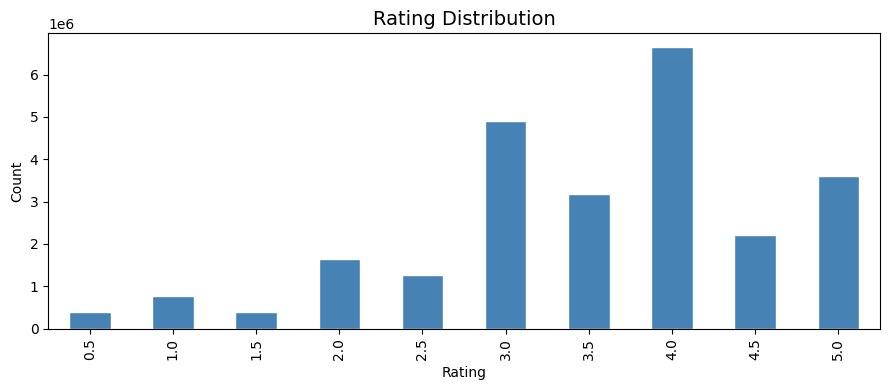

In [16]:
# Ratings distribution

fig, ax = plt.subplots(figsize=(9, 4))
ratings["rating"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Rating Distribution", fontsize=14)
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/rating_dist.png", dpi=150)
plt.show()

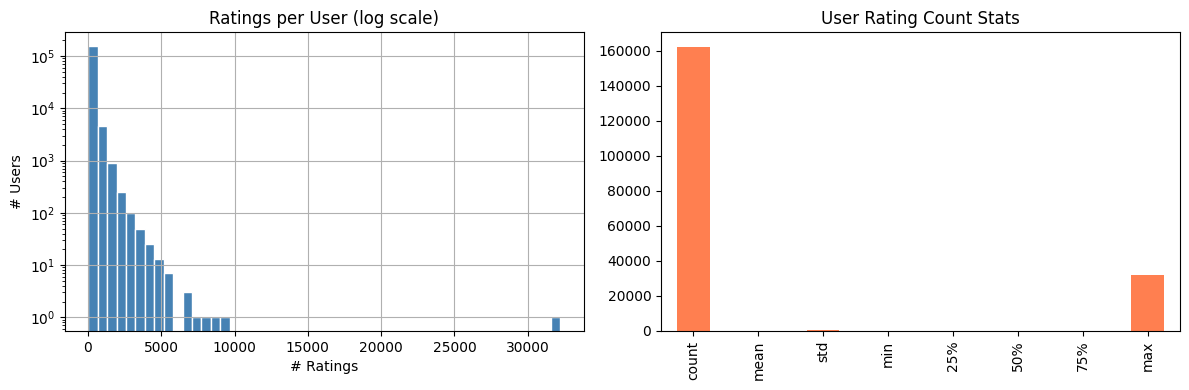

Median ratings per user : 71
Mean ratings per user   : 154
Max ratings per user    : 32202


In [17]:
# Ratings per user

user_counts = ratings.groupby("userId")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

user_counts.hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white", log=True)
axes[0].set_title("Ratings per User (log scale)")
axes[0].set_xlabel("# Ratings")
axes[0].set_ylabel("# Users")

user_counts.describe().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("User Rating Count Stats")
plt.tight_layout()
plt.show()

print(f"Median ratings per user : {user_counts.median():.0f}")
print(f"Mean ratings per user   : {user_counts.mean():.0f}")
print(f"Max ratings per user    : {user_counts.max()}")

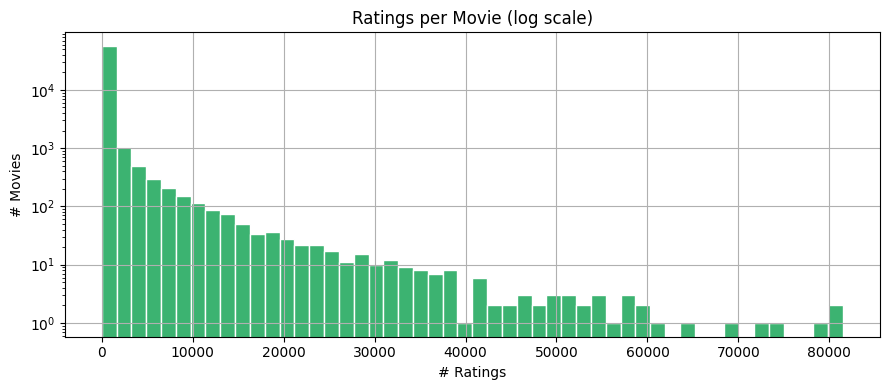

Median ratings per movie: 6
Movies with < 5 ratings : 26,327 (44.6%)


In [18]:
# Ratings per movie

movie_counts = ratings.groupby("movieId")["rating"].count()

fig, ax = plt.subplots(figsize=(9, 4))
movie_counts.hist(bins=50, ax=ax, color="mediumseagreen", edgecolor="white", log=True)
ax.set_title("Ratings per Movie (log scale)")
ax.set_xlabel("# Ratings")
ax.set_ylabel("# Movies")
plt.tight_layout()
plt.show()

print(f"Median ratings per movie: {movie_counts.median():.0f}")
print(f"Movies with < 5 ratings : {(movie_counts < 5).sum():,} ({(movie_counts < 5).mean():.1%})")

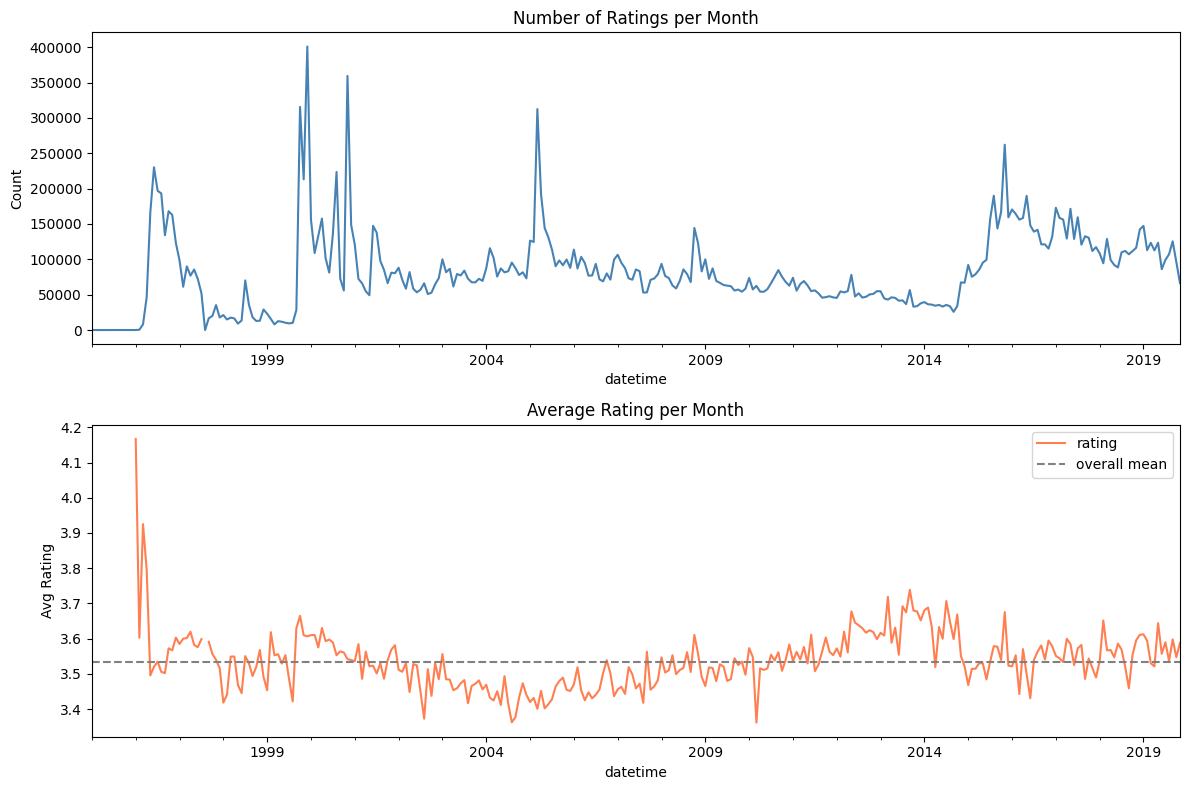

In [21]:
# Temporal Analysis

ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ratings.set_index("datetime")["rating"].resample("ME").count().plot(
    ax=axes[0], color="steelblue"
)
axes[0].set_title("Number of Ratings per Month")
axes[0].set_ylabel("Count")

ratings.set_index("datetime")["rating"].resample("ME").mean().plot(
    ax=axes[1], color="coral"
)
axes[1].set_title("Average Rating per Month")
axes[1].set_ylabel("Avg Rating")
axes[1].axhline(ratings["rating"].mean(), ls="--", color="gray", label="overall mean")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/temporal.png", dpi=150)
plt.show()

In [22]:
# Top 20 most rated movies

top_movies = (
    ratings.groupby("movieId")["rating"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_ratings", "mean": "avg_rating"})
    .merge(movies[["movieId", "title"]], on="movieId")
    .sort_values("n_ratings", ascending=False)
    .head(20)
)
top_movies[["title", "n_ratings", "avg_rating"]]

,title,n_ratings,avg_rating
351,Forrest Gump (1994),81491,4.0480
314,"Shawshank Redemption, The (1994)",81482,4.4136
292,Pulp Fiction (1994),79672,4.1889
585,"Silence of the Lambs, The (1991)",74127,4.1513
2480,"Matrix, The (1999)",72674,4.1541
257,Star Wars: Episode IV - A New Hope (1977),68717,4.1202
475,Jurassic Park (1993),64144,3.6792
522,Schindler's List (1993),60411,4.2476
108,Braveheart (1995),59184,4.0023
2867,Fight Club (1999),58773,4.2283


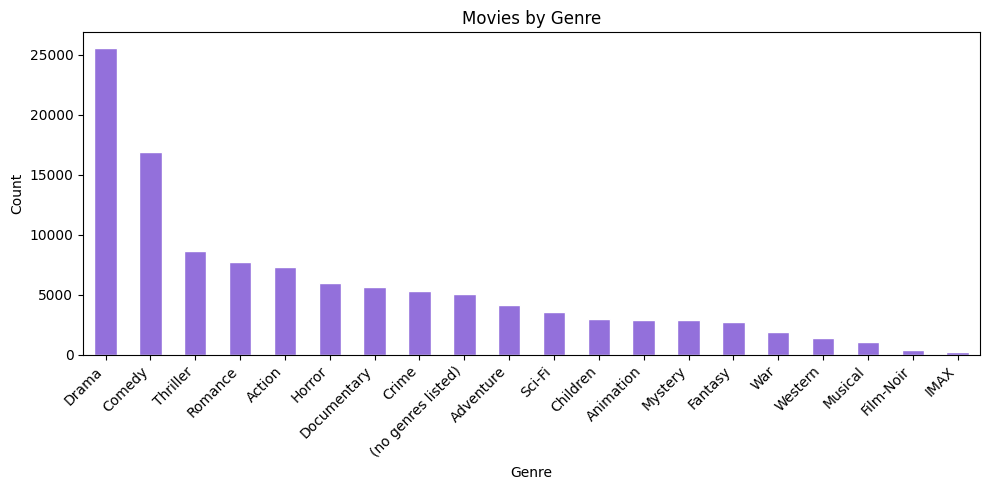

In [23]:
# Genre analysis
genres_exploded = movies["genres"].str.split("|").explode()
genre_counts    = genres_exploded.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
genre_counts.plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("Movies by Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/genres.png", dpi=150)
plt.show()

In [ ]:
# EDA Summary

summary = {
    "n_users": n_users,
    "n_movies": n_movies,
    "n_ratings": n_ratings,
    "sparsity": f"{sparsity:.4%}",
    "mean_rating": round(ratings["rating"].mean(), 4),
    "median_ratings_per_user": user_counts.median(),
    "median_ratings_per_movie": movie_counts.median(),
}

print("📊 EDA Summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\n✅ EDA complete — move to 02_baseline.ipynb")

📊 EDA Summary:
  n_users: 162541
  n_movies: 59047
  n_ratings: 25000095
  sparsity: 99.7395%
  mean_rating: 3.5339
  median_ratings_per_user: 71.0
  median_ratings_per_movie: 6.0

✅ EDA complete — move to 02_baseline.ipynb


: 